# Part 1: Parameter estimation

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 18})
from scipy.integrate import odeint
from scipy.optimize import fmin
from scipy.optimize import minimize
import scipy.stats as stats
import pandas as pd

## Load data

In [2]:
df_Scottish_Gaelic = pd.read_csv("Data/Scottish_Gaelic.csv")
df_Welsh_all_Wales = pd.read_csv("Data/Welsh_all_Wales.csv")

Look at the first couple rows of the data

In [3]:
df_Scottish_Gaelic.head()


,year,speaker_per_100
0,1881,80.40
1,1891,77.10
2,1901,71.75
3,1911,61.75
4,1921,52.25


In [4]:
df_Welsh_all_Wales.head()

,year,speaker_per_100
0,1901,49.9
1,1911,43.5
2,1921,37.1
3,1931,36.8
4,1951,28.9


Plot the data

Text(0, 0.5, 'speaker per 100')

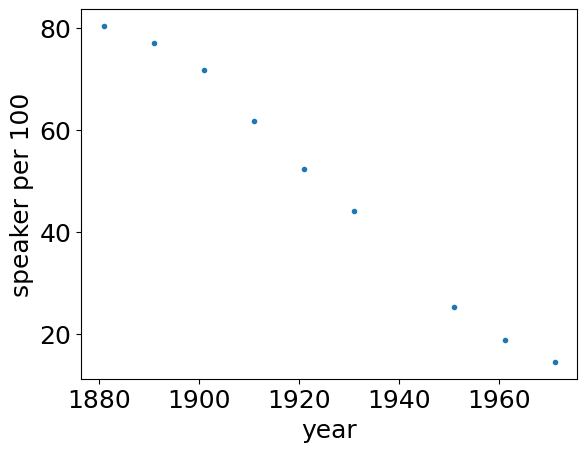

In [5]:
plt.figure()
plt.plot(df_Scottish_Gaelic.year, df_Scottish_Gaelic.speaker_per_100, ".")
plt.xlabel("year")
plt.ylabel("speaker per 100")


Text(0, 0.5, 'speaker per 100')

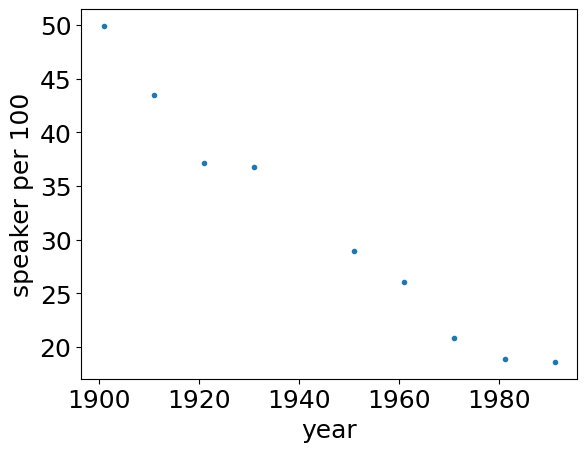

In [6]:
plt.figure()
plt.plot(df_Welsh_all_Wales.year, df_Welsh_all_Wales.speaker_per_100, ".")
plt.xlabel("year")
plt.ylabel("speaker per 100")

## Define the model

In [7]:
def odeSys(x, t, c, s, a):
    """
    Abrams-Strogatz (2003) language death model.

    x - fraction of the population speaking language X (state, in [0, 1])
    t - time
    c - rate constant; sets the timescale only
    s - relative status of X, 0 < s < 1
    a - exponent on speaker share in the conversion probability

    dx/dt = c * [ (1-x) * s * x^a  -  x * (1-s) * (1-x)^a ]
                  \_____________/     \________________/
                   Y speakers -> X      X speakers -> Y
    """
    # x^a with non-integer a is nan for x < 0, and the solver can undershoot
    # below 0 (or past 1) as a trajectory decays toward extinction.
    xc = np.clip(x, 0.0, 1.0)

    dxdt = c * ((1 - xc) * s * xc**a - xc * (1 - s) * (1 - xc)**a)

    return dxdt

## Example of simulating the equation forward in time with some assumed parameters

(0.0, 1.0)

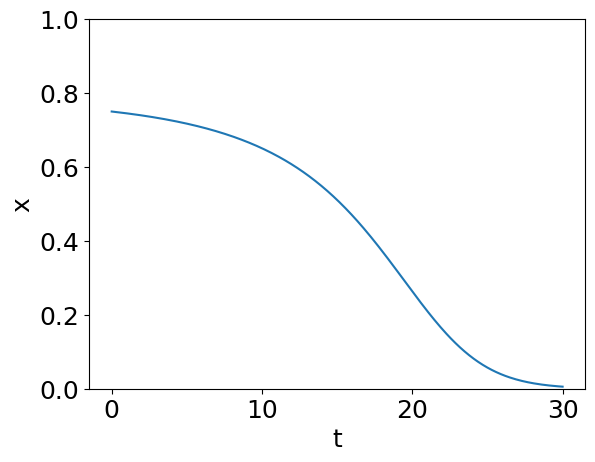

In [8]:
x0 = 0.75       # starting share of X speakers, in [0, 1]
c  = 1.0        # mutiplication coefficient
s  = 0.4        # relative status of X
a  = 1.31       # paper's fitted exponent

# define time
t = np.linspace(0, 30, 300)

sol = odeint(odeSys, x0, t, args=(c, s, a))   # run ode system
x = sol[:, 0]

# plot solution
plt.figure()
plt.plot(t, x, "-")
plt.xlabel("t")
plt.ylabel("x")
plt.ylim(0, 1)

## Part A: Parameter estimation by maximizing log likelihood (all parameters are local)

In [9]:
def neg_LL(par, x_data, t):
    """
    Compute negative log likelihood of data given model
    """
    # extract parameters
    c, s, a, x0, std_dev = par
    # make prediction using model 
    
    sol = odeint(odeSys, x0, t, args = (c, s, a))  # run ode system 
    x_model = sol[:, 0] 

    # Calculate the log-likelihood for normal distribution
    LL = np.sum(stats.norm.logpdf(x_data, x_model, std_dev))
   
    # Calculate the negative log-likelihood
    neg_LL = -1*LL
    return neg_LL 


In [10]:
bounds1 = [(1e-4, 5),     # c
          (0.01, 0.99),  # s
          (0, 2),      # a
          (0.01, 0.99),  # x0
          (1e-4, 0.5)]   # std_dev 

bounds2 = [(1e-4, 5),     # c
          (0.01, 0.99),  # s
          (1, 2),      # a
          (0.01, 0.99),  # x0
          (1e-4, 0.5)]   # std_dev 
          

In [11]:
def fit_language_1(df):
    x_data = df.speaker_per_100.to_numpy() / 100
    t = df.year.to_numpy(dtype=float)

    best = None
    for c0 in [0.01, 0.05, 0.2]:
        for s0 in [0.3, 0.45, 0.7]:
            for a0 in [0.5, 1.1, 1.3, 2.0]:
                par0 = [c0, s0, a0, x_data[0], 0.02]
                optSol = minimize(neg_LL, par0, args=(x_data, t), method="L-BFGS-B", bounds=bounds1)
                if best is None or optSol.fun < best.fun:
                    best = optSol

    return best

def fit_language_2(df):
    x_data = df.speaker_per_100.to_numpy() / 100
    t = df.year.to_numpy(dtype=float)

    best = None
    for c0 in [0.01, 0.05, 0.2]:
        for s0 in [0.3, 0.45, 0.7]:
            for a0 in [0.5, 1.1, 1.3, 2.0]:
                par0 = [c0, s0, a0, x_data[0], 0.02]
                optSol = minimize(neg_LL, par0, args=(x_data, t), method="L-BFGS-B", bounds=bounds2)
                if best is None or optSol.fun < best.fun:
                    best = optSol

    return best

## Plot best fitting model with data 

Scottish Gaelic: c=0.0433, s=0.0100, a=1.1688, x0=0.8186, sd=0.0097
Welsh (all Wales): c=0.0120, s=0.0100, a=0.0659, x0=0.4920, sd=0.0126
Scottish Gaelic: c=0.0433, s=0.0100, a=1.1688, x0=0.8186, sd=0.0097
Welsh (all Wales): c=0.0171, s=0.0100, a=1.0000, x0=0.4809, sd=0.0139


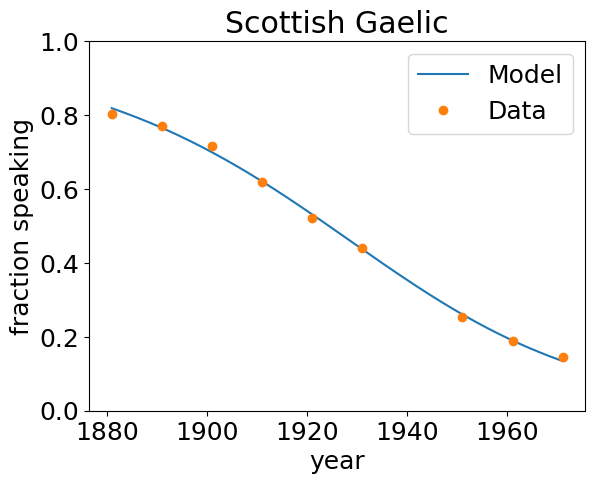

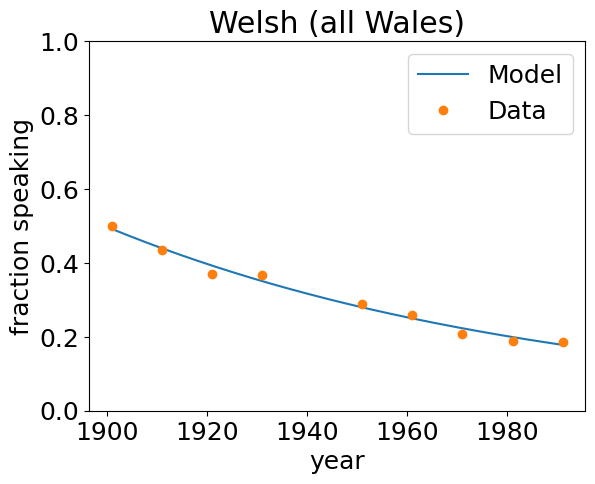

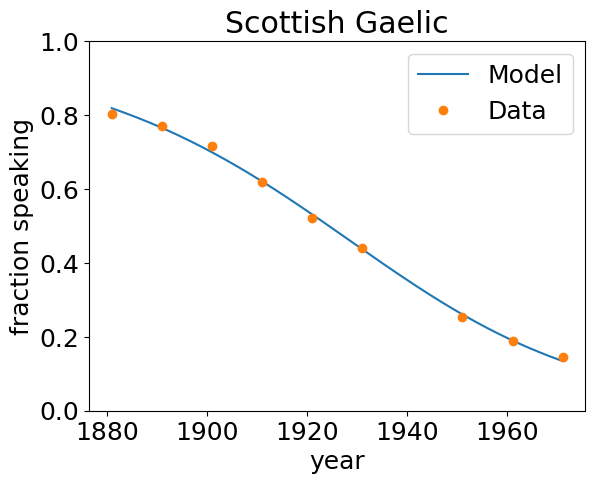

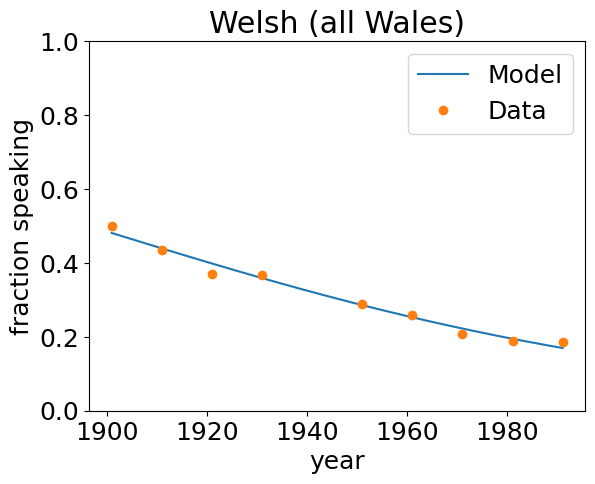

In [12]:
def plot_fit(df, optSol, title):
    c_opt, s_opt, a_opt, x0_opt, std_dev_opt = optSol.x
    t_fine = np.linspace(df.year.min(), df.year.max(), 300)   # starts at x0's year
    sol = odeint(odeSys, x0_opt, t_fine, args=(c_opt, s_opt, a_opt))

    plt.figure()
    plt.plot(t_fine, sol[:, 0], "-")
    plt.plot(df.year, df.speaker_per_100 / 100, ".", markersize=12)
    plt.xlabel("year"); plt.ylabel("fraction speaking"); plt.ylim(0, 1)
    plt.title(title)
    plt.legend(["Model", "Data"])

for name, df in {"Scottish Gaelic": df_Scottish_Gaelic,
                 "Welsh (all Wales)": df_Welsh_all_Wales}.items():
    optSol = fit_language_1(df)
    c, s, a, x0, sd = optSol.x
    print(f"{name}: c={c:.4f}, s={s:.4f}, a={a:.4f}, x0={x0:.4f}, sd={sd:.4f}")
    plot_fit(df, optSol, name)

for name, df in {"Scottish Gaelic": df_Scottish_Gaelic,
                 "Welsh (all Wales)": df_Welsh_all_Wales}.items():
    optSol = fit_language_2(df)
    c, s, a, x0, sd = optSol.x
    print(f"{name}: c={c:.4f}, s={s:.4f}, a={a:.4f}, x0={x0:.4f}, sd={sd:.4f}")
    plot_fit(df, optSol, name)

From the model, we are actually not told on the exploration range of the parameter space, and the impactful choice was how to define the range of a. And bound a to only (1,2) actually gives us a different optimized value for a, and it sits on the lower bound of a at 1, so this probably indicates that the better range is the wider one that include a value smaller than 1. And since this occurs to the Welsh case, so it should be attributed to the data itself. And since we see simply from the 1970-1990 data points a plateau of decrease, that might indicate a stable equlibrium is reached, thus considering the analysis we saw from assignment 1, the corresponding range for a is reasonablely in (0,1).

## Part B: Parameter estimation, a is kept global

In [13]:
def neg_LL_global(par, datasets):
    """
    par = [a,  c1, s1, x01, sd1,  c2, s2, x02, sd2]
    a is shared; each dataset has its own c, s, x0, std_dev.
    """
    a = par[0]
    total = 0.0
    for i, (x_data, t) in enumerate(datasets):
        c, s, x0, std_dev = par[1 + 4*i : 5 + 4*i]
        total += neg_LL([c, s, a, x0, std_dev], x_data, t)
    return total

In [14]:
datasets = [(df.speaker_per_100.values / 100, df.year.values.astype(float))
            for df in [df_Scottish_Gaelic, df_Welsh_all_Wales]]

bounds_global = [(0, 2)] + \
    [(1e-4, 5), (0.0001, 0.99), (0.01, 0.99), (1e-4, 0.5)] * len(datasets)
#      c           s             x0            std_dev

best = None
for a0 in [0.3, 1, 1.5, 1.9]:
    for c0 in [0.01, 0.05, 0.2, 1, 2]:
        for s0 in [0.5, 0.8]:
            par0 = [a0]
            for x_data, t in datasets:
                par0 += [c0, s0, x_data[0], 0.02]

            optSol = minimize(
                neg_LL_global, par0,
                args=(datasets,),
                method="L-BFGS-B",
                bounds=bounds_global,
            )
            if (optSol.success and np.isfinite(optSol.fun)
                    and (best is None or optSol.fun < best.fun)):
                best = optSol

if best is None:
    raise RuntimeError("No starting point produced a successful fit")

a_opt = best.x[0]
print(f"shared a = {a_opt:.4f}")
for i, name in enumerate(["Scottish Gaelic", "Welsh (all Wales)"]):
    c, s, x0, sd = best.x[1 + 4*i : 5 + 4*i]
    print(f"{name}: c={c:.4f}, s={s:.4f}, x0={x0:.4f}, sd={sd:.4f}")

shared a = 1.1625
Scottish Gaelic: c=0.0422, s=0.0001, x0=0.8193, sd=0.0097
Welsh (all Wales): c=0.0179, s=0.0001, x0=0.4790, sd=0.0143


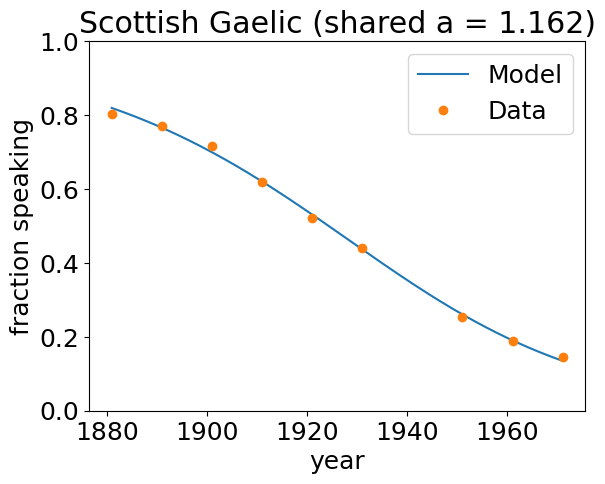

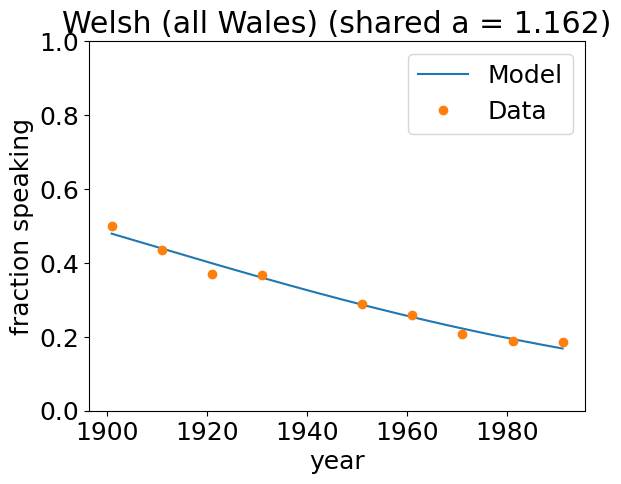

In [15]:
for i, (name, df) in enumerate({"Scottish Gaelic": df_Scottish_Gaelic,
                                "Welsh (all Wales)": df_Welsh_all_Wales}.items()):
    c_opt, s_opt, x0_opt, sd_opt = best.x[1 + 4*i : 5 + 4*i]
    t_fine = np.linspace(df.year.min(), df.year.max(), 300)
    sol = odeint(odeSys, x0_opt, t_fine, args=(c_opt, s_opt, a_opt))

    plt.figure()
    plt.plot(t_fine, sol[:, 0], "-")
    plt.plot(df.year, df.speaker_per_100 / 100, ".", markersize=12)
    plt.xlabel("year"); plt.ylabel("fraction speaking"); plt.ylim(0, 1)
    plt.title(f"{name} (shared a = {a_opt:.3f})")
    plt.legend(["Model", "Data"])

In [16]:
local_fits = {}
for name, df in {"Scottish Gaelic": df_Scottish_Gaelic,
                 "Welsh (all Wales)": df_Welsh_all_Wales}.items():
    local_fits[name] = fit_language_1(df)

## Part C

In [17]:
def BIC(neg_LL_value, k, n):
    return k * np.log(n) + 2 * neg_LL_value

n_total = sum(len(x_data) for x_data, t in datasets)          # 9 + 9 = 18

# local version: a separate for each language
nll_local = sum(opt.fun for opt in local_fits.values())
k_local   = sum(len(opt.x) for opt in local_fits.values())    # 5 + 5 = 10

# global version: a shared
nll_global = best.fun
k_global   = len(best.x)                                       # 1 + 4 + 4 = 9

BIC_local  = BIC(nll_local,  k_local,  n_total)
BIC_global = BIC(nll_global, k_global, n_total)

print(f"Local : k={k_local},  -LL={nll_local:.3f},  BIC={BIC_local:.3f}")
print(f"Global: k={k_global},  -LL={nll_global:.3f},  BIC={BIC_global:.3f}")
print(f"ΔBIC (local − global) = {BIC_local - BIC_global:.3f}")

Local : k=10,  -LL=-55.525,  BIC=-82.145
Global: k=9,  -LL=-54.353,  BIC=-82.693
ΔBIC (local − global) = 0.548


Just from the results, the delta BIC value is small so that the two models are actually not preferred over one another. And what's weird from the results are that all of the inferred s value reached the imposed lower bound, so they might not be the precise estimate of the underlying parameter values.

# Part 2 Synchronization

This is really interesting phenomenon and would be interested in understanding what math approaches are there in explaining the phenomenon, but one concern is that the potential math behind the broad synchronization phenomena seems a bit involved, so I'm wondering for social scientists what are the more intuitive and readily avaliable tools in exploring comparable phenomena.
Parallels of synchronization phenomena in social systems: 
1. During concert or a live sporting event, the audience can form sychronized chanting or waving.
2. We probably have all experienced sitting in a large classroom while people are chatting, but all of a sudden the entire classroom gets weirdly quiet.
